In [1]:
import ants

### Readin images

In [2]:
T1_baseline = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_CVR/bids/derivatives/deepprep_baselineT1/BOLD/sub-001/anat/sub-001_desc-preproc_T1w.nii.gz")
T1_6m = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_CVR/bids/derivatives/deepprep_6mT1/BOLD/sub-001/anat/sub-001_desc-preproc_T1w.nii.gz")

In [3]:
FLAIR_baseline = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/sub-001/ses-baseline/anat/sub-001_ses-baseline_FLAIR.nii.gz")
FLAIR_6m = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/sub-001/ses-6m/anat/sub-001_ses-6m_FLAIR.nii.gz")

### Pre-longitudinal registration

In [ ]:
trans_baseline = ants.registration(
    fixed=FLAIR_baseline,
    moving=T1_baseline, 
    type_of_transform='Rigid',
    verbose=True
)
T1_baseline_r2FLAIR = trans_baseline['warpedmovout']

antsRegistration -d 3 -r [0000016F20404E28,0000016F206A68A8,1] -m mattes[0000016F20404E28,0000016F206A68A8,1,32,regular,0.2] -t Rigid[0.25] -c 2100x1200x1200x10 -s 3x2x1x0 -f 6x4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmp6ile_uk2,0000016F20404EC8,0000016F20404E68] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1


In [6]:
trans_6m = ants.registration(
    fixed=FLAIR_6m,
    moving=T1_6m, 
    type_of_transform='Rigid',
    verbose=True
)
T1_6m_r2FLAIR = trans_6m['warpedmovout']

antsRegistration -d 3 -r [0000016F204079E8,0000016F20407E48,1] -m mattes[0000016F204079E8,0000016F20407E48,1,32,regular,0.2] -t Rigid[0.25] -c 2100x1200x1200x10 -s 3x2x1x0 -f 6x4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmpjxswcmu9,0000016F20199B88,0000016F204040C8] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1


In [7]:
trans_prelong = ants.registration(
    fixed=FLAIR_baseline,
    moving=FLAIR_6m, 
    type_of_transform='Rigid',
    verbose=True
)
FLAIR_6m_r2baseline = trans_prelong['warpedmovout']

antsRegistration -d 3 -r [0000016F20BD3868,0000016F20198FA8,1] -m mattes[0000016F20BD3868,0000016F20198FA8,1,32,regular,0.2] -t Rigid[0.25] -c 2100x1200x1200x10 -s 3x2x1x0 -f 6x4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmplqc0fs3k,0000016F2019B008,0000016F2019A588] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1


### Validation of pre-longitudinal registration 

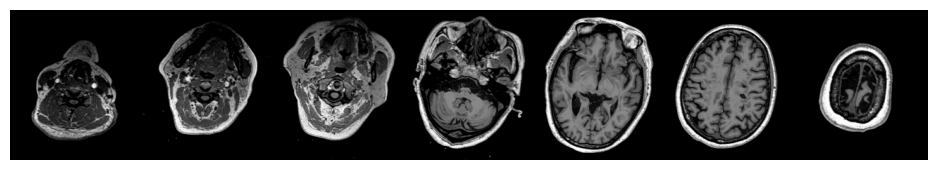

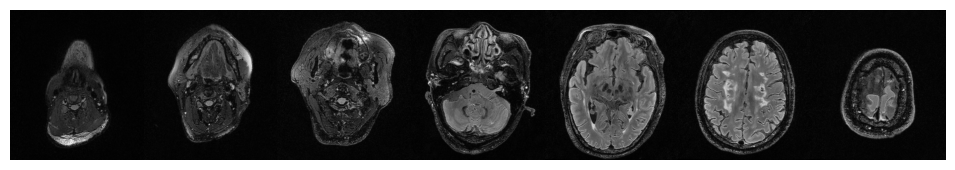

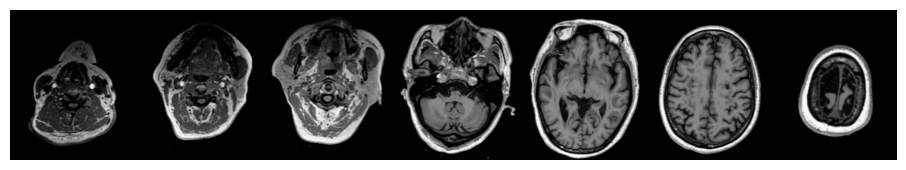

In [8]:
ants.plot(T1_baseline, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(FLAIR_baseline, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(T1_baseline_r2FLAIR, nslices=7, ncol=7, axis=2, crop=True)

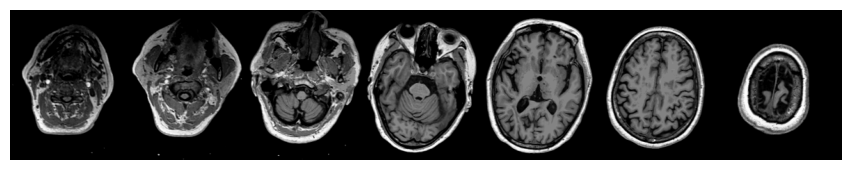

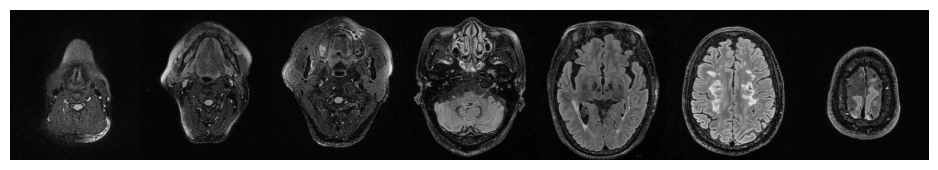

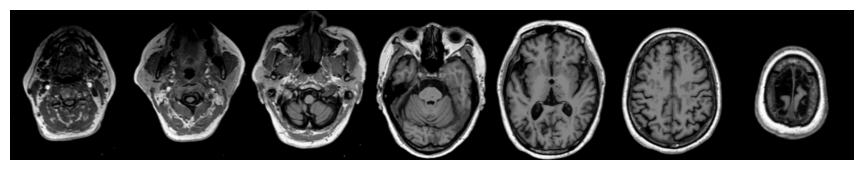

In [9]:
ants.plot(T1_6m, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(FLAIR_6m, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(T1_6m_r2FLAIR, nslices=7, ncol=7, axis=2, crop=True)

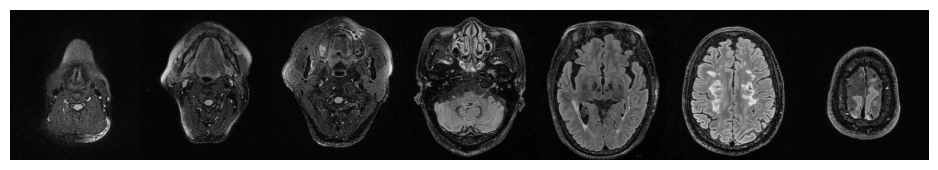

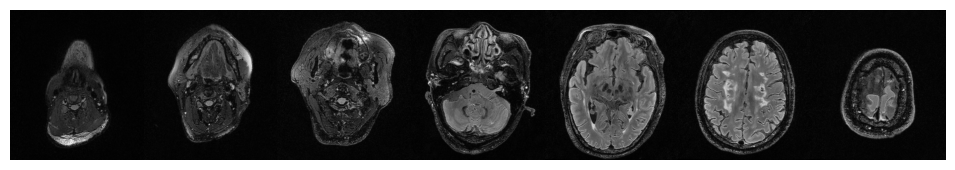

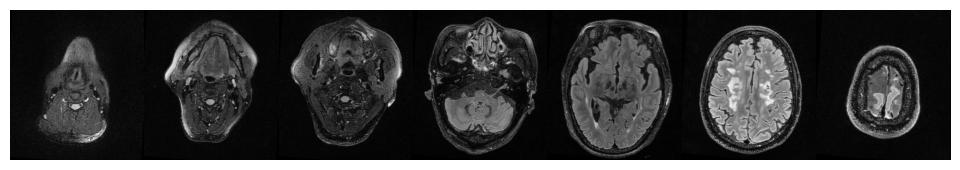

In [10]:
ants.plot(FLAIR_6m, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(FLAIR_baseline, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(FLAIR_6m_r2baseline, nslices=7, ncol=7, axis=2, crop=True)

### Longitudinal registration

# ANTs Registration of FLAIR to T1w

In [ ]:
trans_baseline = ants.registration(
    fixed=template_baselineT1,
    moving=toreg_baselineFLAIR, 
    type_of_transform='SyN',
    verbose=True
)
trans_6m = ants.registration(
    fixed=template_6mT1,
    moving=toreg_6mFLAIR, 
    type_of_transform='SyN',
    verbose=True
)
reged_baselineFLAIR = trans_baseline['warpedmovout']


antsRegistration -d 3 -r [000002228E688468,000002228CACE4A8,1] -m mattes[000002228E688468,000002228CACE4A8,1,32,regular,0.2] -t Affine[0.25] -c 2100x1200x1200x0 -s 3x2x1x0 -f 4x2x2x1 -x [NA,NA] -m mattes[000002228E688468,000002228CACE4A8,1,32] -t SyN[0.200000,3.000000,0.000000] -c [40x20x0,1e-7,8] -s 2x1x0 -f 4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmpxulqfzo1,00000222F74AFD08,000002228CDBEF48] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1
antsRegistration -d 3 -r [00000222F74AE368,00000222F74ADFC8,1] -m mattes[00000222F74AE368,00000222F74ADFC8,1,32,regular,0.2] -t Affine[0.25] -c 2100x1200x1200x0 -s 3x2x1x0 -f 4x2x2x1 -x [NA,NA] -m mattes[00000222F74AE368,00000222F74ADFC8,1,32] -t SyN[0.200000,3.000000,0.000000] -c [40x20x0,1e-7,8] -s 2x1x0 -f 4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmp_3sf5x8o,00000222F74ADEC8,00000222F74ADB28] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1


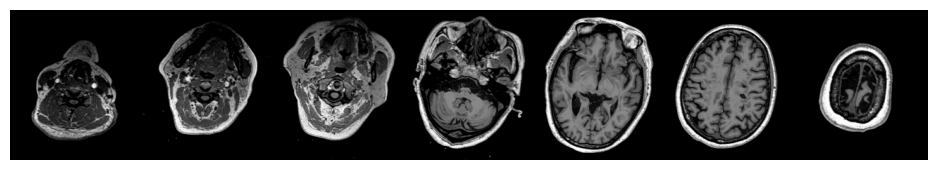

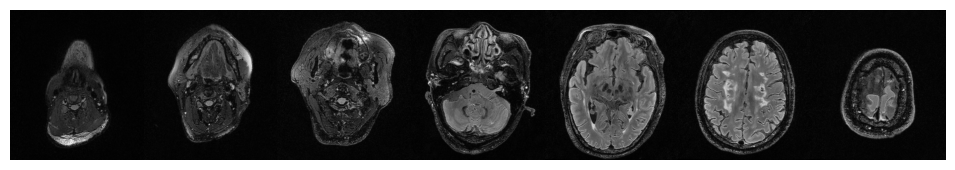

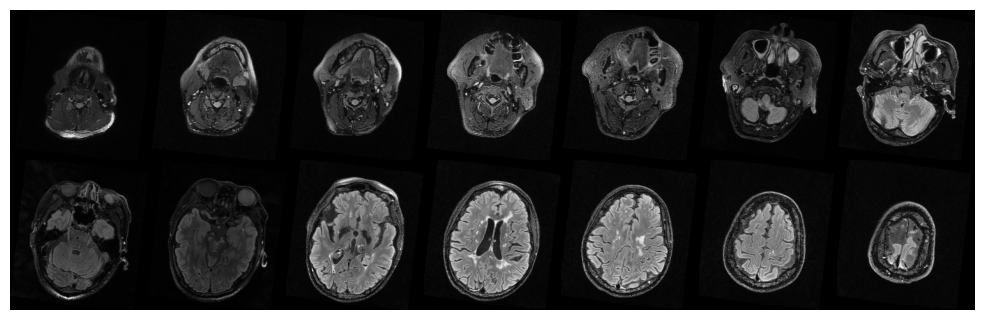

In [7]:
reged_baselineFLAIR = trans_baseline['warpedmovout']

ants.plot(template_baselineT1, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(toreg_baselineFLAIR, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(reged_baselineFLAIR, nslices=14, ncol=7, axis=2, crop=True)

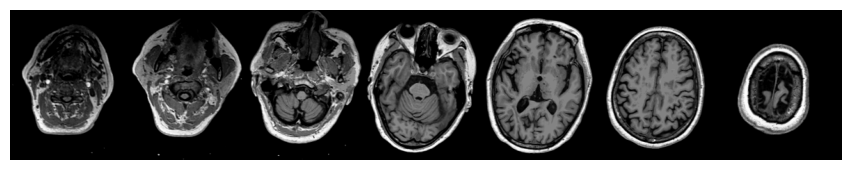

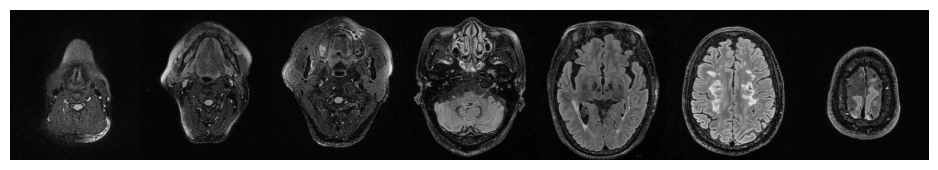

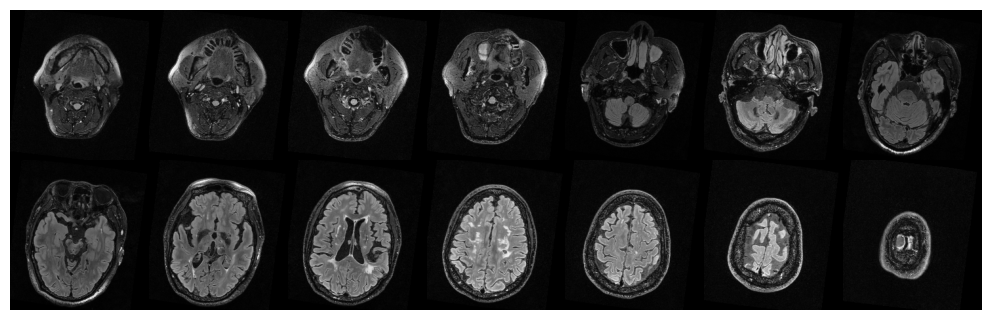

In [8]:
reged_6mFLAIR = trans_6m['warpedmovout']

ants.plot(template_6mT1, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(toreg_6mFLAIR, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(reged_6mFLAIR, nslices=14, ncol=7, axis=2, crop=True)

# Export

In [9]:
reged_baselineFLAIR.to_file("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/ANTs/reged_baselineFLAIR.nii.gz")
reged_6mFLAIR.to_file("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/ANTs/reged_6mFLAIR.nii.gz")

# Import Template and Raw Images

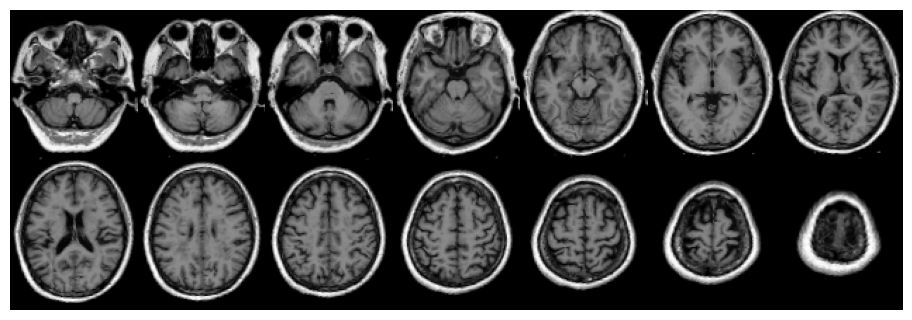

In [8]:
template_baselineT1 = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_CVR/bids/derivatives/deepprep_baselineT1/BOLD/sub-001/anat/sub-001_space-MNI152NLin6Asym_res-02_desc-skull_T1w.nii.gz")
ants.plot(template_baselineT1, nslices=14, ncol=7, axis=2, crop=True)

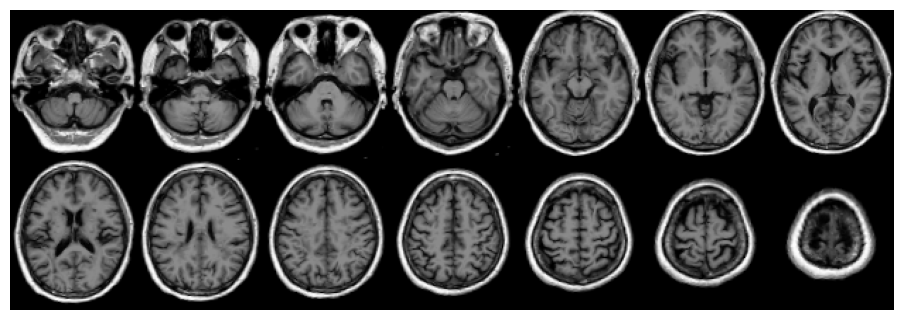

In [9]:
template_6mT1 = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_CVR/bids/derivatives/deepprep_6mT1/BOLD/sub-001/anat/sub-001_space-MNI152NLin6Asym_res-02_desc-skull_T1w.nii.gz")
ants.plot(template_6mT1, nslices=14, ncol=7, axis=2, crop=True)

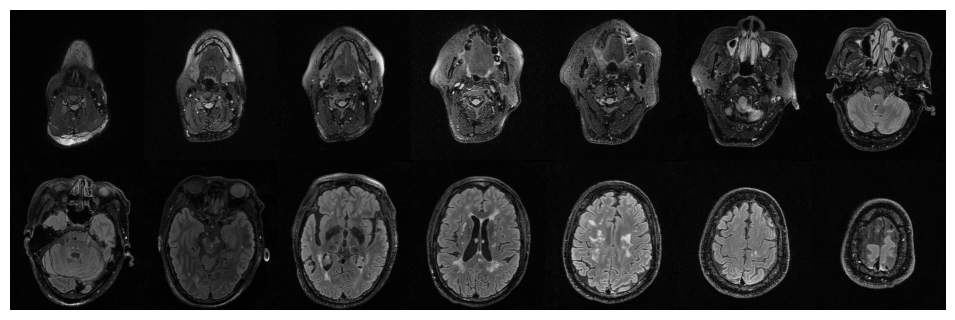

In [10]:
toreg_baselineFLAIR = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/sub-001/ses-baseline/anat/sub-001_ses-baseline_FLAIR.nii.gz")
ants.plot(toreg_baselineFLAIR, nslices=14, ncol=7, axis=2, crop=True)

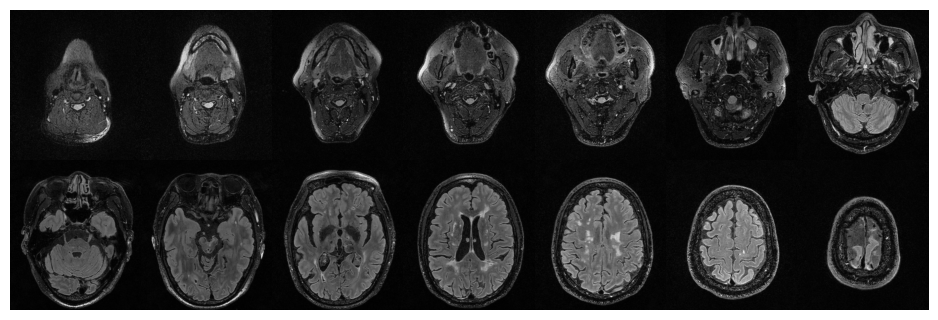

In [11]:
toreg_6mFLAIR = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/sub-001/ses-6m/anat/sub-001_ses-6m_FLAIR.nii.gz")
ants.plot(toreg_6mFLAIR, nslices=14, ncol=7, axis=2, crop=True)

# ANTs Registration of FLAIR to T1w

In [12]:
trans_baseline = ants.registration(
    fixed=template_baselineT1,
    moving=toreg_baselineFLAIR, 
    type_of_transform='SyN',
    verbose=True
)
trans_6m = ants.registration(
    fixed=template_6mT1,
    moving=toreg_6mFLAIR, 
    type_of_transform='SyN',
    verbose=True
)

antsRegistration -d 3 -r [0000025CAEA0D2E8,0000025CAEA0FD48,1] -m mattes[0000025CAEA0D2E8,0000025CAEA0FD48,1,32,regular,0.2] -t Affine[0.25] -c 2100x1200x1200x0 -s 3x2x1x0 -f 4x2x2x1 -x [NA,NA] -m mattes[0000025CAEA0D2E8,0000025CAEA0FD48,1,32] -t SyN[0.200000,3.000000,0.000000] -c [40x20x0,1e-7,8] -s 2x1x0 -f 4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmpceiingoe,0000025CAEDC00A8,0000025CAEA0E5C8] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1
antsRegistration -d 3 -r [0000025CAEA0FD48,0000025CAF69B348,1] -m mattes[0000025CAEA0FD48,0000025CAF69B348,1,32,regular,0.2] -t Affine[0.25] -c 2100x1200x1200x0 -s 3x2x1x0 -f 4x2x2x1 -x [NA,NA] -m mattes[0000025CAEA0FD48,0000025CAF69B348,1,32] -t SyN[0.200000,3.000000,0.000000] -c [40x20x0,1e-7,8] -s 2x1x0 -f 4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmpov0gumbp,0000025CAEA0E5C8,0000025CAEA0FE68] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1


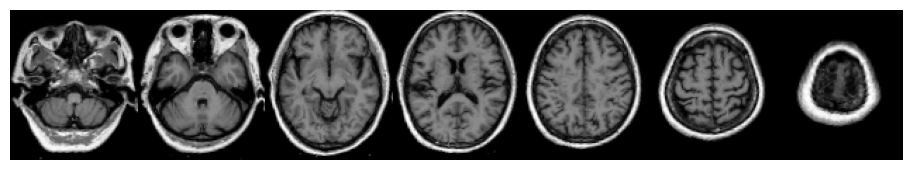

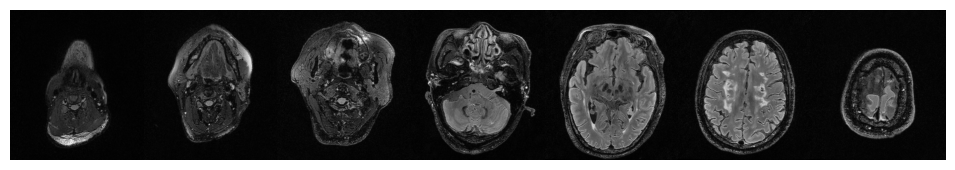

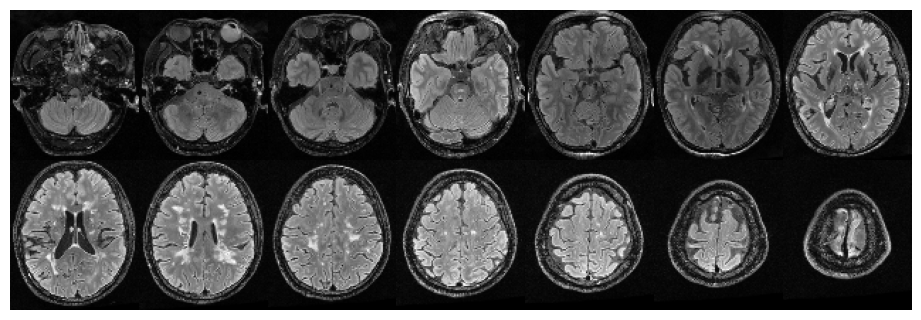

In [13]:
reged_baselineFLAIR = trans_baseline['warpedmovout']

ants.plot(template_baselineT1, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(toreg_baselineFLAIR, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(reged_baselineFLAIR, nslices=14, ncol=7, axis=2, crop=True)

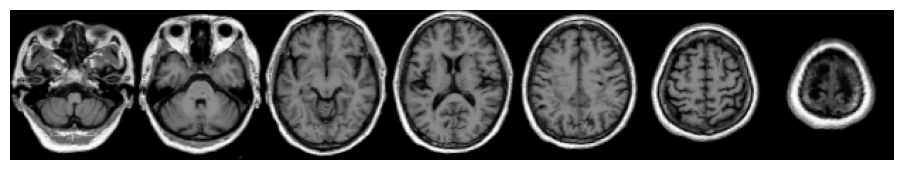

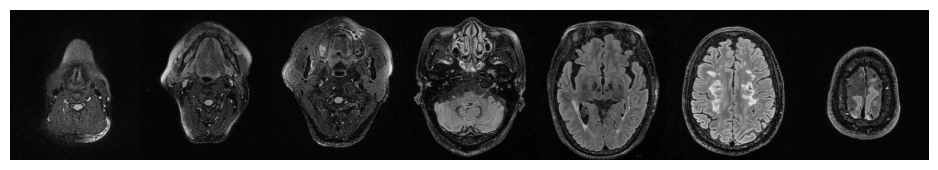

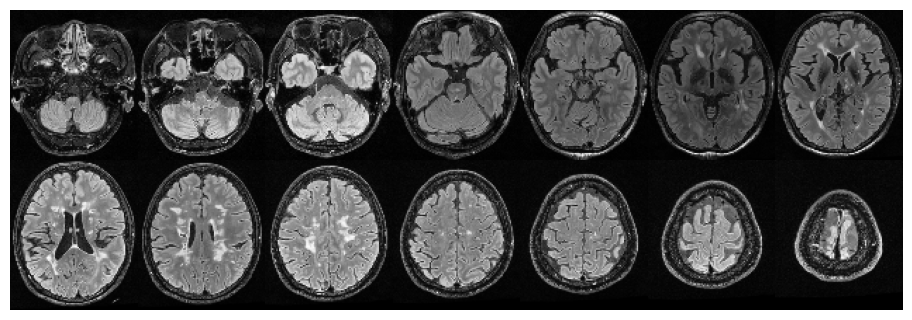

In [14]:
reged_6mFLAIR = trans_6m['warpedmovout']

ants.plot(template_6mT1, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(toreg_6mFLAIR, nslices=7, ncol=7, axis=2, crop=True)
ants.plot(reged_6mFLAIR, nslices=14, ncol=7, axis=2, crop=True)

# Export

In [15]:
reged_baselineFLAIR.to_file("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/ANTs/MNI_baselineFLAIR.nii.gz")
reged_6mFLAIR.to_file("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/ANTs/MNI_6mFLAIR.nii.gz")